HEART metrics analysis notebook for Stack Overflow

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Plot style
sns.set_theme(style="whitegrid")

In [3]:
# Connect to the SQLite database
conn = sqlite3.connect("stackoverflow.db")

1. Adoption: New Users per Month

In [4]:
users = pd.read_sql("SELECT Id, CreationDate FROM users", conn)
users['CreationDate'] = pd.to_datetime(users['CreationDate'], errors='coerce')
users['YearMonth'] = users['CreationDate'].dt.to_period('M')

In [5]:
adoption = users.groupby('YearMonth').size().reset_index(name='NewUsers')
adoption['YearMonth'] = adoption['YearMonth'].astype(str)

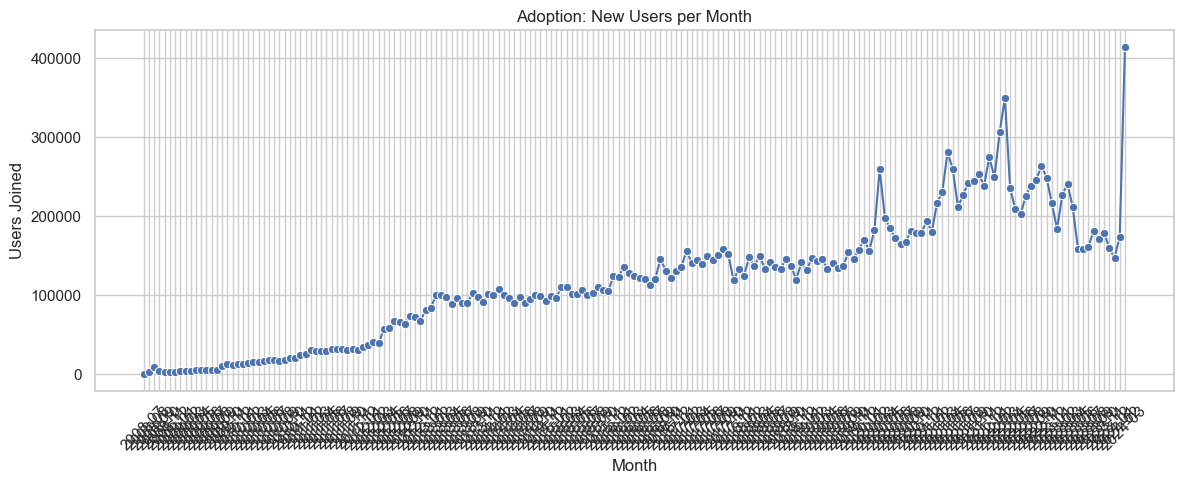

In [6]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=adoption, x='YearMonth', y='NewUsers', marker='o')
plt.xticks(rotation=45)
plt.title("Adoption: New Users per Month")
plt.xlabel("Month")
plt.ylabel("Users Joined")
plt.tight_layout()
plt.show()

Trying different plot

In [7]:
users_df = users

# Convert CreationDate to datetime and extract year-month
users_df['CreationDate'] = pd.to_datetime(users_df['CreationDate'], errors='coerce')
users_df['YearMonth'] = users_df['CreationDate'].dt.to_period('M').astype(str)

In [8]:
# Group by month and count users
monthly_users = users_df.groupby('YearMonth').size().reset_index(name='NewUsers')

In [9]:
# Sort by date for plotting
monthly_users = monthly_users.sort_values('YearMonth')

In [10]:
# Set Seaborn style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

<Figure size 1600x600 with 0 Axes>

<Figure size 1600x600 with 0 Axes>

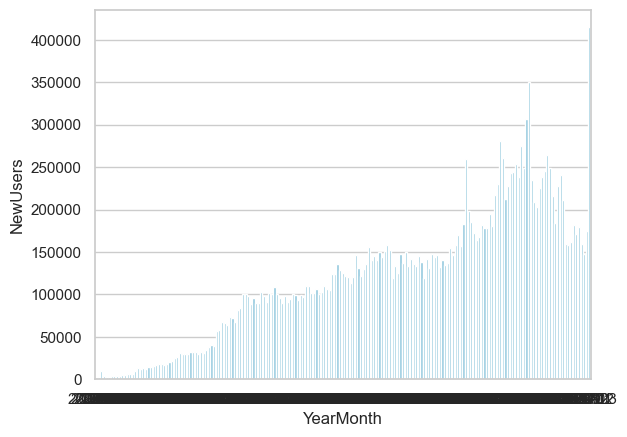

In [11]:
# Barplot
ax = sns.barplot(data=monthly_users, x="YearMonth", y="NewUsers", color='skyblue')

In [12]:
# Improve x-axis labels
xtick_labels = monthly_users['YearMonth']
if len(xtick_labels) > 30:
    step = len(xtick_labels) // 30
    ax.set_xticks(range(0, len(xtick_labels), step))
    ax.set_xticklabels(xtick_labels[::step], rotation=45, ha='right')
else:
    ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

C:\Users\Ola\AppData\Local\Temp\ipykernel_22572\2603829215.py:5: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Ola\git\stackoverflow-heart-metrics\data-analysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


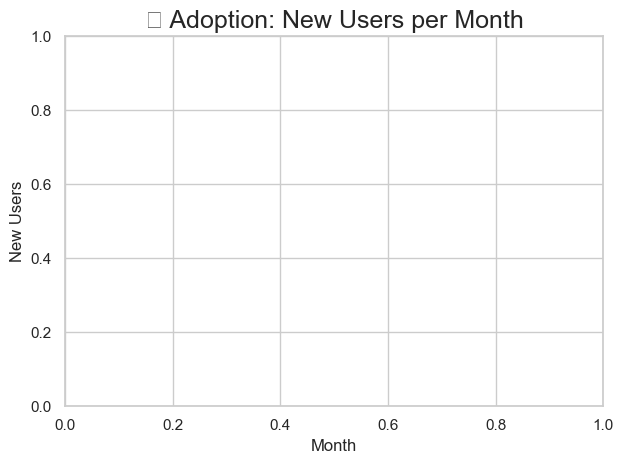

In [13]:
# Titles and labels
plt.title("📈 Adoption: New Users per Month", fontsize=18)
plt.xlabel("Month")
plt.ylabel("New Users")
plt.tight_layout()
plt.show()

C:\Users\Ola\AppData\Local\Temp\ipykernel_22572\2412984179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=monthly_users, x="YearMonth", y="NewUsers", palette="viridis")


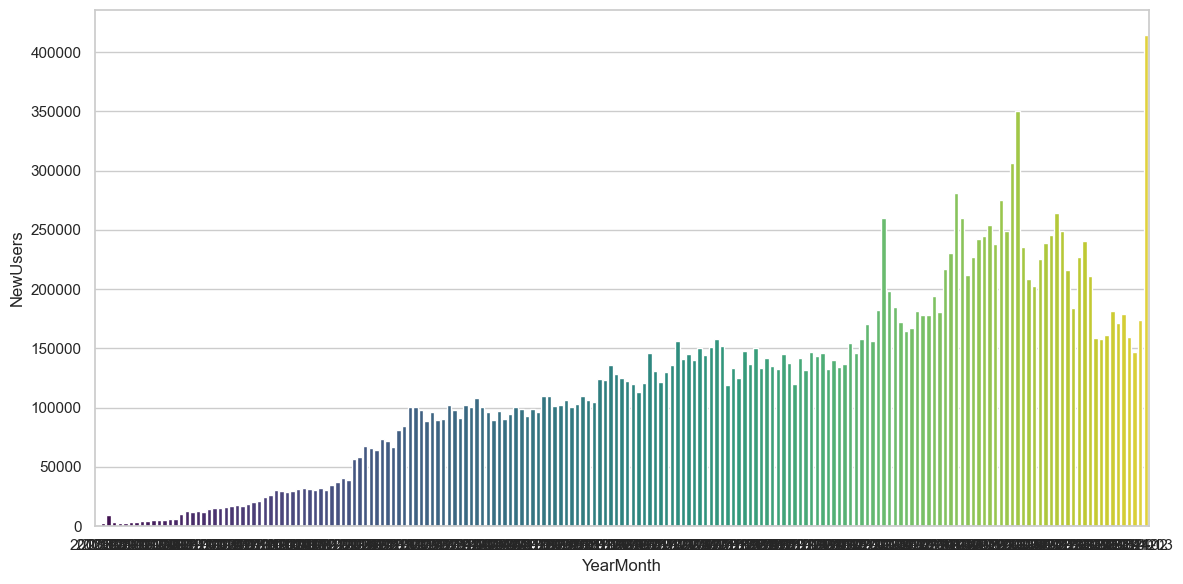

In [16]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=monthly_users, x="YearMonth", y="NewUsers", hue="viridis")
plt.tight_layout()

In [18]:
# Create a list with the desired pattern
year_month_pattern = []
unique_years = users_df['YearMonth'].str.split('-').str[0].unique()
for year in unique_years:
    year_month_pattern.append(year)
    year_month_pattern.extend([' '] * (users_df['yearmonth'].str.startswith(year).sum() - 1))

ax.set_xticklabels(year_month_pattern)

# Show the plot
plt.tight_layout()
plt.show()